In [15]:
import h5py
import numpy as np
import pathlib 
import matplotlib.pyplot as plt
import os
from scipy import signal
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tables

# sizes
# udam 322
# 04 161
# 12 161
# 16 161
# 24 161
# max index 966


# data collection
p = pathlib.Path('c:/Users/nmuccioli/Documents/Project Data')

rawdata = []
speices = []
tspeices = []
temp = []
pitchdata = []

df_rows = []
for x in p.iterdir():
    if x.is_dir():
        for y in x.iterdir():
            if y.is_dir():
                for z in y.iterdir():
                    if z.name == "pc_f60kHz.h5":
                        f = h5py.File(z,'r')
                        rawdata.append(f['pitchcatch/catch'])  
                        pitchdata.append(f['pitchcatch/pitch'])
                        temp.append(f['CTC/Temperature'])
                        speices.append(x.name)
                        diff = 10
                        for i in range(19,70,diff):
                            if i <= f['CTC/Temperature'][0] < i+diff :
                                tspeices.append(f"{i} - {i+diff} ")
                        



In [16]:
# Transducer pairs (ID) 6, 51

# (IDs for prime pairs)
#Left matlab right Python
# 1&7  6 5
# 2&8  17 16
# 3&9  27 26
# 4&10  36 35
# 5&11  44 43
# 7&12  51 50


prime = [5,16,26,35,43,50]
Fs = 10E6
Fn = Fs / 2
Fc = 20000
Wn = Fc / Fn
b, a = signal.butter(3, Wn, 'highpass')

prepdata = np.zeros_like(rawdata)
for i in range(len(rawdata)):
    for j in range(len(rawdata[0])):
        prepdata[i][j] = signal.filtfilt(b, a, rawdata[i][j])





In [ ]:
#data processing
#optimal baseline selection (OBS) and baseline signal stretch (BSS)
start = 81
subdata = np.zeros(((len(prepdata) - start),len(prepdata[0]),len(prepdata[0][0])))

ref = prepdata[0:start]
for i in range(0,len(subdata)):
            subdata[i] = np.subtract(prepdata[i + start], ref[(int(temp[i+start][0]-20 * 2) )])
        

# Sampling frequency (Hz)
Fs = 10E6
# Time interval between samples
Ts = 1.0/Fs 
# Number of sample points
N = 13108
#number
n = 10

pdata = np.zeros((len(subdata),len(subdata[0]),6,n))

for i in range(0,len(subdata)):
    for j in range(0,len(prime)):
        f, pxx_den = signal.periodogram(subdata[i,j],Fs,nfft=262144,window=signal.windows.kaiser(len(subdata[i,j]),14))
        #max magnitude of frequencies
        top_n_indices = np.argpartition(pxx_den, len(pxx_den) - n)[-n:]
        pdata[i,j,0] = pxx_den[top_n_indices]

        # max magnitudes
        top_n_indices = np.argpartition(subdata[i][prime[j]], len(subdata[0][0]) - n)[-n:]
        pdata[i,j,1] = subdata[i][prime[j]][top_n_indices]
        #cross correlation lag
        correlation = signal.correlate( rawdata[i + start][prime[3]],pitchdata[i + start][prime[3]], mode="full")
        lags = signal.correlation_lags(rawdata[i + start][prime[3]].size,pitchdata[i + start][prime[3]].size, mode="full")
        lag = lags[np.argmax(correlation)]
        if lag < 5000 and lag > 1000:
            pdata[i,j,3] = lag

    pdata[i,:,2] = temp[i + start]
    



In [49]:
sdata = np.zeros((2,len(pdata)))
sdata[0] =  pdata[:,3,2,1].reshape(len(pdata) )
sdata[1] = pdata[:,3,3,1].reshape(len(pdata) ) 
sdata[1] = sdata[1] / Fs

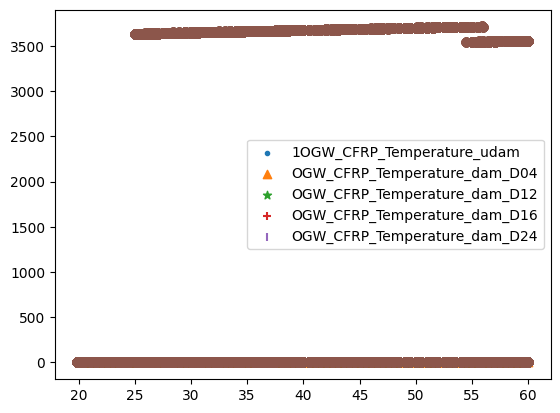

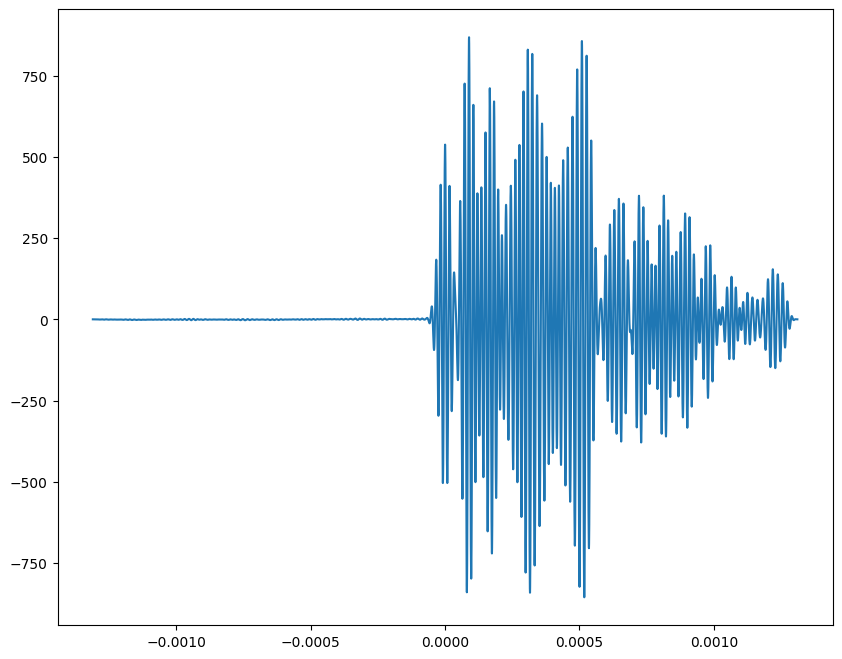

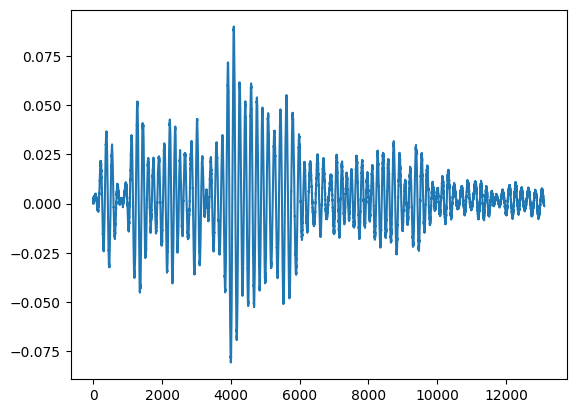

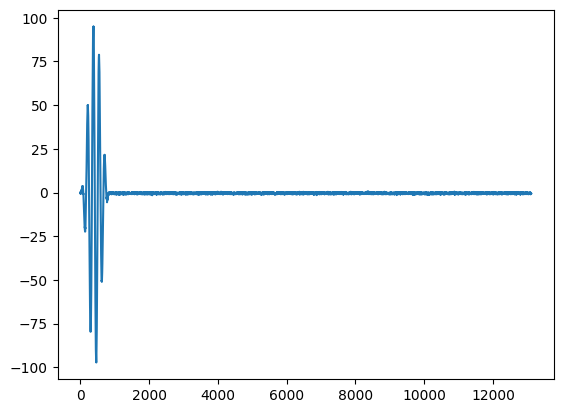

In [50]:

row_speices = []
for i in range(len(speices)):
   row_speices.append( speices[i//len(prime)])
#print(len(row_speices))


tempdf = pd.DataFrame(data=sdata.T, columns=['temp','wave speed'])
tempdf['target'] = speices[start:len(speices)]
markers = ['.','^','*','+','|']
i=0
for target in tempdf['target'].unique():
    subset = tempdf[tempdf['target'] == target]
    plt.scatter(subset['temp'],subset['wave speed'], label = target, marker=markers[i])
    i+=1
    
plt.legend()
#plt.ylim(3640,3650)
#plt.ylim(-13100,-13120)
#plt.xlim(20,21)
plt.scatter(pdata[:,:,2].reshape(len(pdata) * len(pdata[0])* len(pdata[0][0][0])),pdata[:,:,3].reshape(len(pdata) * len(pdata[0])* len(pdata[0][0][0])))
plt.show()
plt.figure(figsize=(10,8))

plt.plot(lags,correlation)
plt.show()
plt.plot(rawdata[100][prime[3]])
plt.show()
plt.plot(pitchdata[100][prime[3]])


<Figure size 1000x800 with 0 Axes>

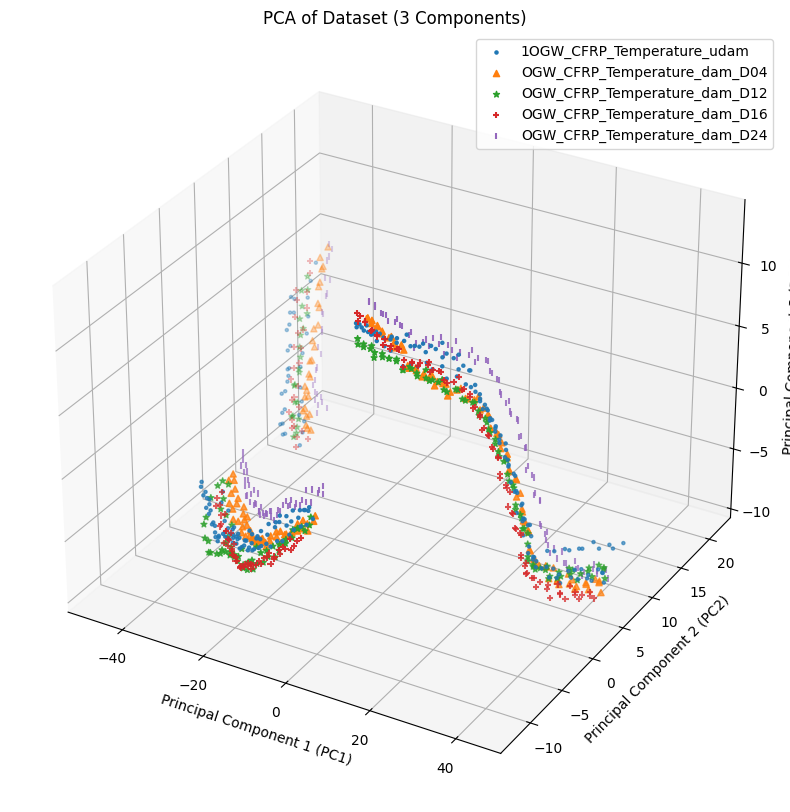

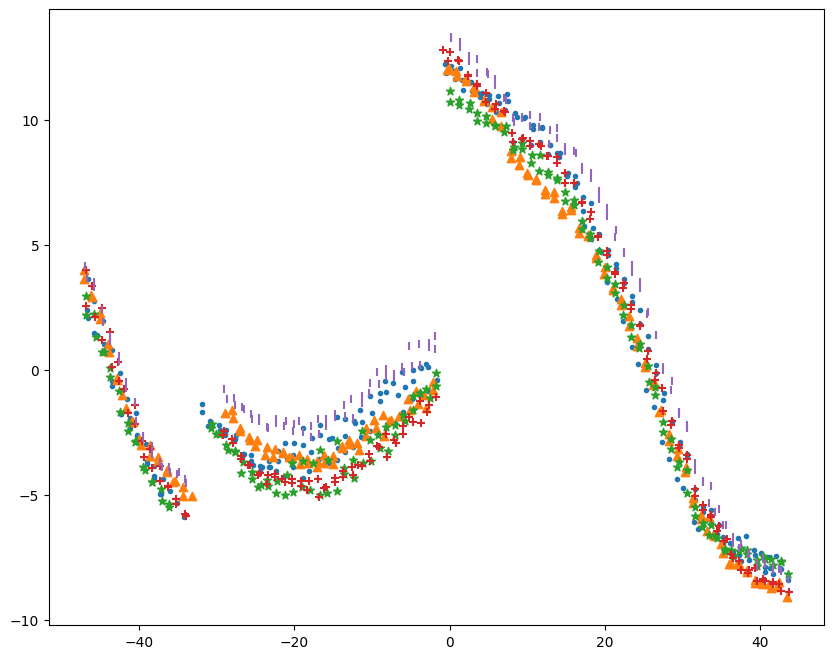

<Figure size 1000x800 with 0 Axes>

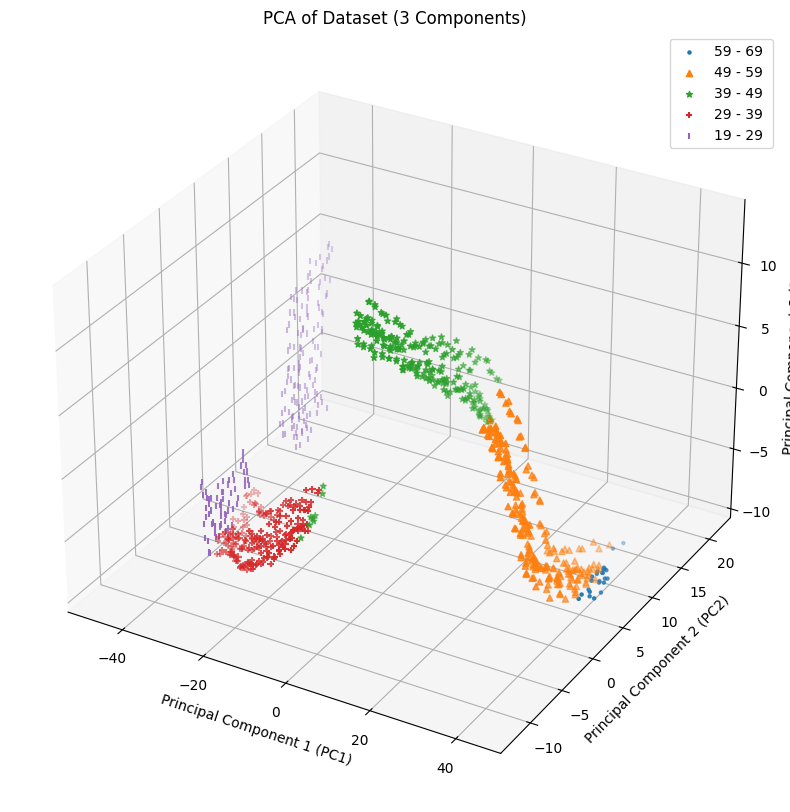

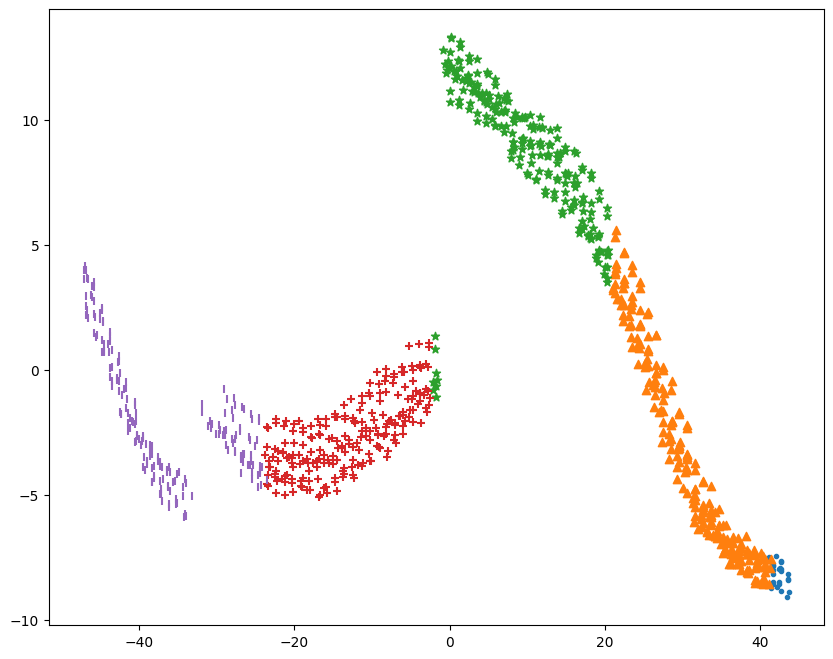

In [19]:
#PCA Fitting


pca = PCA(n_components=3)
scaler = StandardScaler()

pcadata = pdata[:,:,:,:].reshape(len(pdata),len(pdata[0]) * (len(pdata[0,0]) ) * len(pdata[0,0,0]))
datascaled = scaler.fit_transform(pcadata)
datapca = pca.fit_transform(datascaled)

plt.figure(figsize=(10,8))
#pca_df = pd.DataFrame(data=datapca, columns=['PC1'])
pca_df = pd.DataFrame(data=datapca, columns=['PC1', 'PC2', 'PC3'])
pca_df['target'] = speices[start:len(speices)]

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(projection='3d')

i = 0
markers = ['.','^','*','+','|']
for target in pca_df['target'].unique():
    subset = pca_df[pca_df['target'] == target]
    ax.scatter(subset['PC1'],subset['PC2'], subset['PC3'], label = target, marker=markers[i])
    i+=1
    #plt.scatter(subset['PC1'],subset['PC1'], label = target)


ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')
#ax.set_xlim((-5,6))
ax.set_title('PCA of Dataset (3 Components)')
ax.legend()


plt.figure(figsize=(10,8))
i = 0
markers = ['.','^','*','+','|']
for target in pca_df['target'].unique():
    subset = pca_df[pca_df['target'] == target]
    plt.scatter(subset['PC1'],subset['PC3'], label = target, marker=markers[i])
    i+=1
#plt.xlim(-5,6)
datascaled = scaler.fit_transform(pcadata)
datapca = pca.fit_transform(datascaled)

plt.figure(figsize=(10,8))
#pca_df = pd.DataFrame(data=datapca, columns=['PC1'])
pca_df = pd.DataFrame(data=datapca, columns=['PC1', 'PC2', 'PC3'])
pca_df['target'] = tspeices[start:len(tspeices)]

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(projection='3d')

i = 0
markers = ['.','^','*','+','|']
for target in pca_df['target'].unique():
    subset = pca_df[pca_df['target'] == target]
    ax.scatter(subset['PC1'],subset['PC2'], subset['PC3'], label = target, marker=markers[i])
    i+=1
    #plt.scatter(subset['PC1'],subset['PC1'], label = target)


ax.set_xlabel('Principal Component 1 (PC1)')
ax.set_ylabel('Principal Component 2 (PC2)')
ax.set_zlabel('Principal Component 3 (PC3)')
#ax.set_xlim((-5,6))
ax.set_title('PCA of Dataset (3 Components)')
ax.legend()

plt.figure(figsize=(10,8))
i = 0
markers = ['.','^','*','+','|']
for target in pca_df['target'].unique():
    subset = pca_df[pca_df['target'] == target]
    plt.scatter(subset['PC1'],subset['PC3'], label = target, marker=markers[i])
    i+=1
#plt.xlim((-5,6))



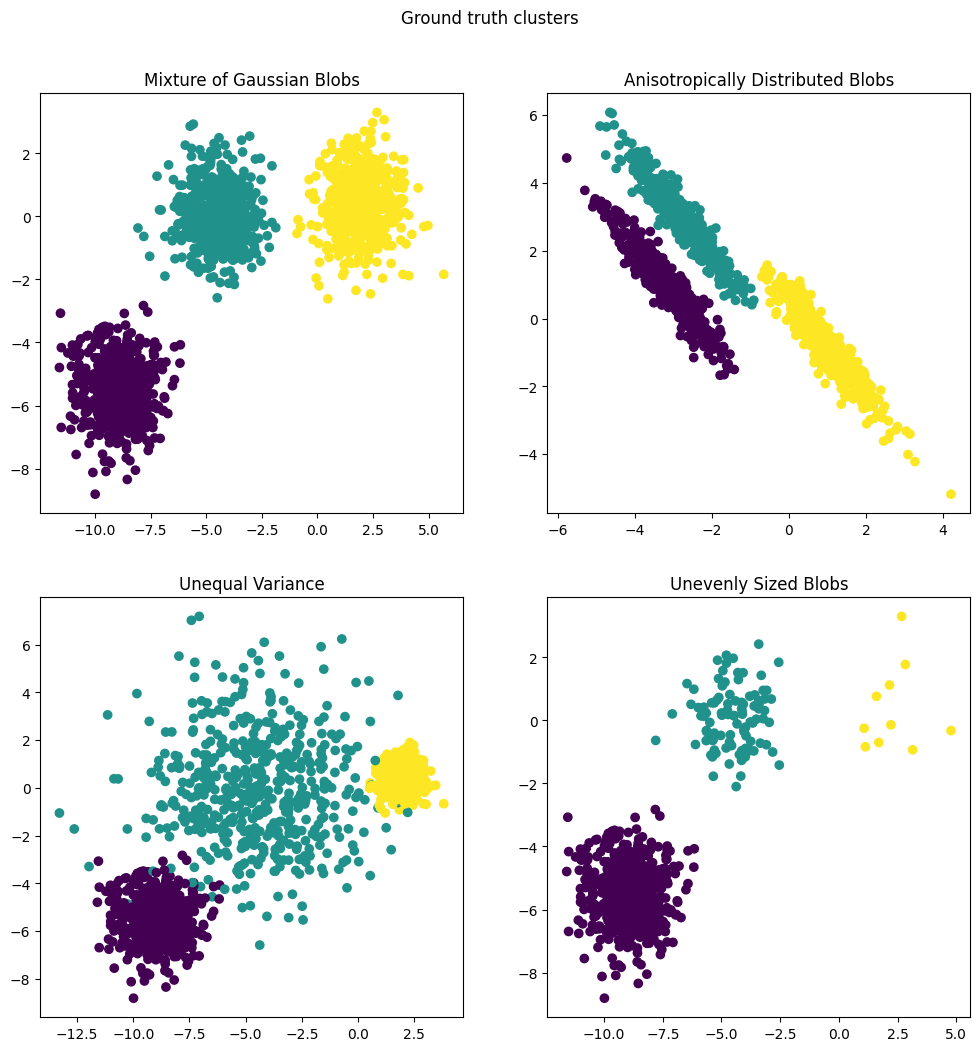

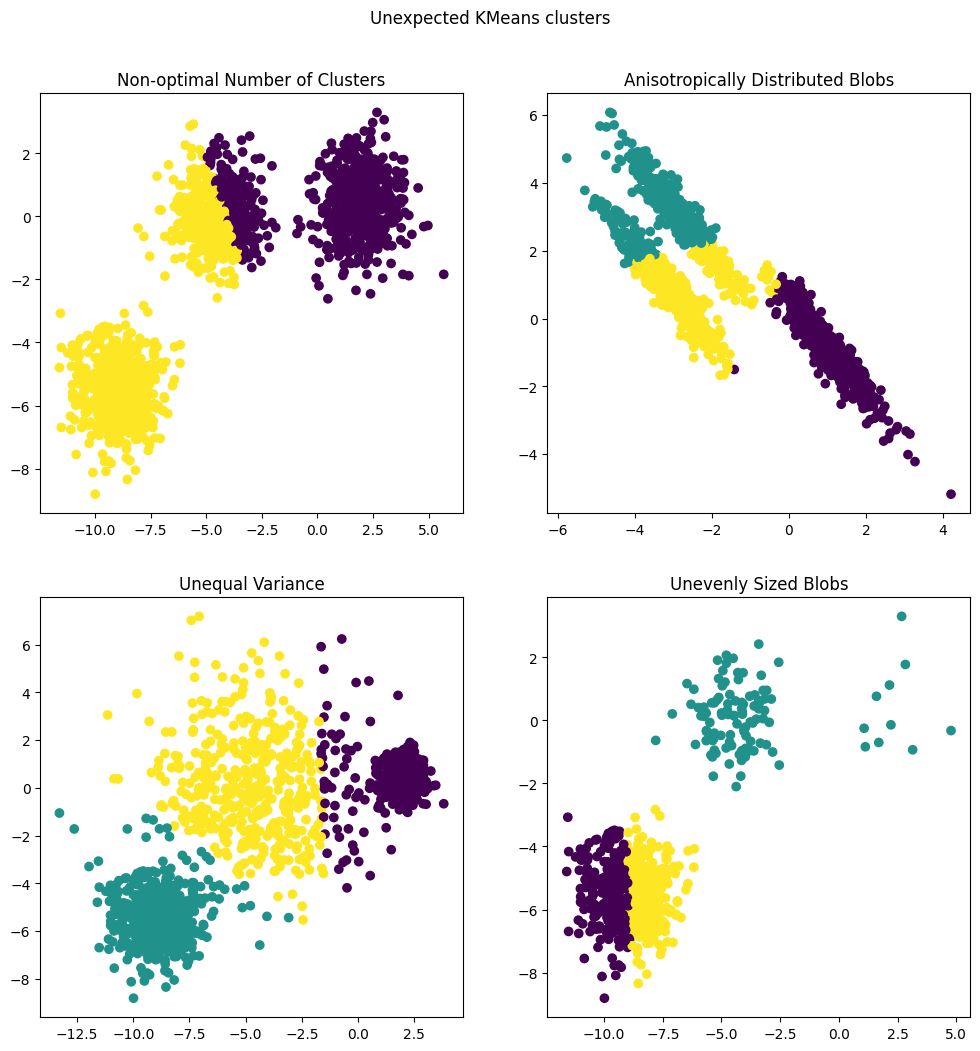

In [20]:
import numpy as np

from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
    "random_state": random_state,
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

y_pred = KMeans(n_clusters=2, **common_params).fit_predict(X)
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_aniso)
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_varied)
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 0].set_title("Unequal Variance")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_filtered)
axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()